# THE GRIDBREAKERS: GIẢI MÃ GEN DOANH THU & TÁI CẤU TRÚC VẬN HÀNH 
*(Báo cáo Phân tích Dữ liệu - Datathon 2026)*

## Bối cảnh: Một thập kỷ chuyển mình (2012 - 2022)
Bộ dữ liệu ghi nhận hành trình 10 năm vận hành của một doanh nghiệp thương mại điện tử thời trang tại Việt Nam. Sống sót và liên tục mở rộng quy mô trong suốt một thập kỷ tại một thị trường khốc liệt là một thành tựu đáng tự hào. Trong giai đoạn này, chiến lược trọng tâm của doanh nghiệp rõ ràng là **Thâu tóm thị phần**.

Tuy nhiên, khi thị trường bước vào giai đoạn bão hòa và chi phí thu hút khách hàng ngày càng đắt đỏ, quy mô doanh thu không còn là bảo chứng cho sự tồn tại. Đã đến lúc doanh nghiệp phải chuyển dịch trọng tâm sang **Chất lượng dòng tiền và Tối ưu hóa vận hành**.

Với triết lý *"Biến dữ liệu thành giải pháp"*, nhóm nghiên cứu đã tiến hành khai phá sự liên kết của 4 lớp dữ liệu: Master, Transaction, Analytical và Operational.

Chúng tôi bắt đầu bằng việc đặt bức tranh "Thành tựu" cạnh lăng kính "Tài chính" để đo lường sức khỏe thực sự của doanh nghiệp:

## 1. Mở đầu: Ảo ảnh của Quy mô và Báo động đỏ của Biên lợi nhuận (The Illusion of Scale & Margin Crisis)

Nhìn từ bề ngoài, doanh nghiệp đang sở hữu những chỉ số vận hành "trong mơ" của ngành thương mại điện tử thời trang:
* **Mức độ gắn kết cao:** Tỷ lệ khách hàng quay lại (Returning Customers) vô cùng ấn tượng.
* **Quy mô giỏ hàng lớn:** Phần lớn các đơn hàng đều chứa từ 2 sản phẩm trở lên.

Tuy nhiên, khi đối chiếu với hiệu quả tài chính, một nghịch lý lớn xuất hiện. Dù sở hữu tệp khách hàng trung thành sẵn sàng chi tiêu nhiều, **Biên lợi nhuận gộp (Gross Margin)** của doanh nghiệp lại liên tục bị nén chặt ở ngưỡng rủi ro trong suốt thập kỷ qua. 

Chính sự đối lập này đặt ra câu hỏi lớn nhất cho toàn bộ chuỗi vận hành: **Tiền của chúng ta đang bị rò rỉ ở đâu?**

C:\Users\OS\AppData\Local\Temp\ipykernel_27572\1612515713.py:12: DtypeWarning: Columns (0: promo_id_2) have mixed types. Specify dtype option on import or set low_memory=False.
  df_order_items = pd.read_csv(os.path.join(DATA_DIR, 'order_items.csv'))


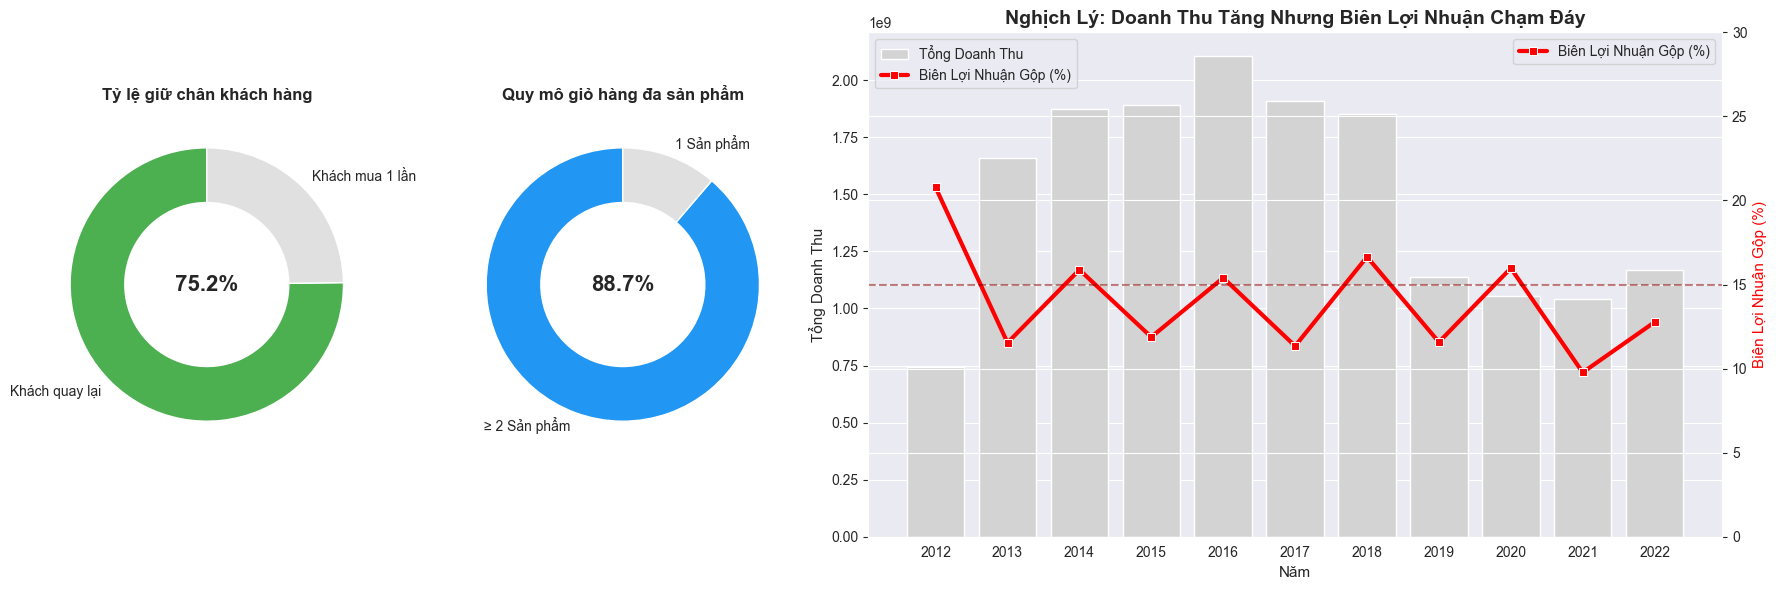

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import numpy as np

# 1. Thiết lập đường dẫn dữ liệu
DATA_DIR = r"../data/raw"

# 2. Đọc các bảng dữ liệu cần thiết
df_orders = pd.read_csv(os.path.join(DATA_DIR, 'orders.csv'))
df_order_items = pd.read_csv(os.path.join(DATA_DIR, 'order_items.csv'))
df_sales = pd.read_csv(os.path.join(DATA_DIR, 'sales.csv'))

# ==========================================
# PHẦN XỬ LÝ DỮ LIỆU ĐỂ LẤY SỐ LIỆU THỰC TẾ
# ==========================================

# A. Tính tỷ lệ khách hàng quay lại (Retention Rate)
customer_order_counts = df_orders.groupby('customer_id')['order_id'].nunique()
returning_customers = (customer_order_counts > 1).sum()
total_customers = len(customer_order_counts)
retention_rate = returning_customers / total_customers * 100

# B. Tính tỷ lệ đơn hàng đa sản phẩm (Basket Size > 1)
# Group theo order_id và đếm số lượng product_id khác nhau hoặc tổng quantity
items_per_order = df_order_items.groupby('order_id')['quantity'].sum()
multi_item_orders = (items_per_order >= 2).sum()
total_orders = len(items_per_order)
multi_item_rate = multi_item_orders / total_orders * 100

# C. Tính Biên lợi nhuận gộp (Gross Margin) theo năm
df_sales['Date'] = pd.to_datetime(df_sales['Date'])
df_sales['Year'] = df_sales['Date'].dt.year
yearly_financials = df_sales.groupby('Year')[['Revenue', 'COGS']].sum().reset_index()
# Công thức: (Revenue - COGS) / Revenue * 100
yearly_financials['Gross_Margin_Pct'] = ((yearly_financials['Revenue'] - yearly_financials['COGS']) / yearly_financials['Revenue']) * 100

# ==========================================
# PHẦN TRỰC QUAN HOÁ (DASHBOARD 1x3)
# ==========================================
fig = plt.figure(figsize=(18, 6))
# Cấu trúc lưới: 2 biểu đồ tròn nhỏ bên trái, 1 biểu đồ lớn bên phải
gs = fig.add_gridspec(1, 3, width_ratios=[1, 1, 2.5]) 

# --- Subplot 1: Donut chart Tỷ lệ giữ chân ---
ax1 = fig.add_subplot(gs[0])
ax1.pie([retention_rate, 100 - retention_rate], 
        labels=['Khách quay lại', 'Khách mua 1 lần'], 
        colors=['#4CAF50', '#E0E0E0'], 
        startangle=90, wedgeprops={'width': 0.4})
ax1.text(0, 0, f"{retention_rate:.1f}%", ha='center', va='center', fontsize=16, fontweight='bold')
ax1.set_title("Tỷ lệ giữ chân khách hàng", fontsize=12, fontweight='bold', pad=10)

# --- Subplot 2: Donut chart Quy mô giỏ hàng ---
ax2 = fig.add_subplot(gs[1])
ax2.pie([multi_item_rate, 100 - multi_item_rate], 
        labels=['≥ 2 Sản phẩm', '1 Sản phẩm'], 
        colors=['#2196F3', '#E0E0E0'], 
        startangle=90, wedgeprops={'width': 0.4})
ax2.text(0, 0, f"{multi_item_rate:.1f}%", ha='center', va='center', fontsize=16, fontweight='bold')
ax2.set_title("Quy mô giỏ hàng đa sản phẩm", fontsize=12, fontweight='bold', pad=10)

# --- Subplot 3: Doanh thu vs Biên lợi nhuận gộp ---
ax3 = fig.add_subplot(gs[2])
# Vẽ cột Doanh thu
sns.barplot(data=yearly_financials, x='Year', y='Revenue', color='lightgrey', ax=ax3, label='Tổng Doanh Thu')
ax3.set_ylabel('Tổng Doanh Thu', fontsize=11)
ax3.set_xlabel('Năm', fontsize=11)

# Vẽ đường Biên lợi nhuận gộp trên trục Y thứ 2
ax4 = ax3.twinx()
sns.lineplot(data=yearly_financials, x=np.arange(len(yearly_financials)), y='Gross_Margin_Pct', 
             color='red', marker='s', linewidth=3, ax=ax4, label='Biên Lợi Nhuận Gộp (%)')
ax4.set_ylabel('Biên Lợi Nhuận Gộp (%)', fontsize=11, color='red')
ax4.set_ylim(0, 30) # Cố định trục Y để làm nổi bật việc margin thấp (dưới 20%)
ax4.axhline(15, color='darkred', linestyle='--', alpha=0.5) # Đường baseline cảnh báo

ax3.set_title("Nghịch Lý: Doanh Thu Tăng Nhưng Biên Lợi Nhuận Chạm Đáy", fontsize=14, fontweight='bold')

# Hợp nhất Legend
lines_1, labels_1 = ax3.get_legend_handles_labels()
lines_2, labels_2 = ax4.get_legend_handles_labels()
ax3.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left')

plt.tight_layout()
plt.show()

### Đi tìm điểm rò rỉ: Thiết lập Cây Giả Thuyết (Hypothesis Tree)

Đứng trước sự sụt giảm của Biên lợi nhuận gộp trong khi quy mô vẫn mở rộng, chúng tôi tiến hành "bắt mạch" dòng tiền dựa trên cấu trúc chi phí (Cost Structure) cốt lõi của một doanh nghiệp thương mại điện tử. 

Dòng tiền chỉ có thể rò rỉ qua hai cửa ngõ lớn nhất. Chúng tôi đặt ra 2 giả thuyết cần kiểm chứng:

1. **Cửa ngõ Marketing (Chi phí Thu hút/Giữ chân):** Liệu chiến lược tung mã giảm giá (Promotions) có đang thực sự kích cầu khối lượng lớn, hay chúng ta chỉ đang tự "cắt máu" lợi nhuận để trợ giá cho những khách hàng vốn dĩ đã có nhu cầu tự nhiên?

2. **Cửa ngõ Vận hành & Chuỗi cung ứng (Chi phí Logistics):** Quy mô giỏ hàng lớn là một tín hiệu tốt, nhưng nếu tỷ lệ hủy/hoàn trả (Returns) của những giỏ hàng này cao, liệu chi phí logistics thu hồi có đang trở thành một "chi phí ẩn" nuốt chửng lợi nhuận gộp?

Hãy cùng đi vào lớp dữ liệu Giao dịch (Transaction) và Khuyến mãi (Master) để giải phẫu Giả thuyết số 1.

### Giả thuyết 1: Sự thất bại của Chiến dịch Khuyến mãi và Nghịch lý Biên lợi nhuận

Khuyến mãi của nhãn hàng này hoàn toàn thất bại và chỉ là một cỗ máy đốt biên lợi nhuận

*Khi nhìn vào biên lợi nhuận mỏng manh 10-16%, thoạt nhìn chúng ta tưởng doanh nghiệp đang phải vật lộn giảm giá để cạnh tranh. Nhưng khi bóc tách sâu vào cấp độ đơn hàng, nhóm chúng tôi phát hiện ra một nghịch lý: Thương hiệu không thiếu nhu cầu tự nhiên, nhưng họ đang vận hành một chiến lược khuyến mãi sai lầm.*

*Họ dùng mã giảm giá rải đều như 'mưa ném qua cửa sổ' suốt nửa năm. Hậu quả là tệp khách hàng trung thành - những người sẵn sàng mua giá gốc - lại liên tục được áp mã. Nhãn hàng đang tự cắt máu biên lợi nhuận của chính mình mà không đổi lại được một sự bùng nổ doanh thu hay tệp khách mới nào. Để lật ngược thế cờ, doanh nghiệp cần dừng ngay việc sale đại trà, và chuyển ngân sách đó thành chi phí thu hút (CAC) nhắm mục tiêu chuẩn xác vào tập khách hàng mới*

## 4.1. Cấp độ Descriptive: What happened? (Hiện trạng Nghịch lý Khuyến mãi)

Việc định lượng hiệu suất của các chương trình khuyến mãi đã bộc lộ một bức tranh vận hành cực kỳ kém hiệu quả, thể hiện qua sự mất cân đối nghiêm trọng giữa nỗ lực và kết quả:

- **Tần suất lạm dụng nhưng hiệu suất âm:** Doanh nghiệp đang duy trì các chương trình khuyến mãi với tần suất dày đặc, bao phủ tới **44.5%** tổng số ngày trong năm. Tuy nhiên, khối lượng thời gian khổng lồ này chỉ mang lại **41.5%** tổng doanh thu.
- **Hệ số nhân doanh thu (Multiplier) dưới mức tiêu chuẩn:** Thay vì tạo ra các đỉnh doanh thu (spikes) bùng nổ, doanh thu trung bình ngày có khuyến mãi (Promo Day) thậm chí chỉ bằng **0.9 lần** so với một ngày bán hàng nguyên giá bình thường. Các chiến dịch giảm giá hoàn toàn thất bại trong việc kích cầu khối lượng lớn (Volume lift).

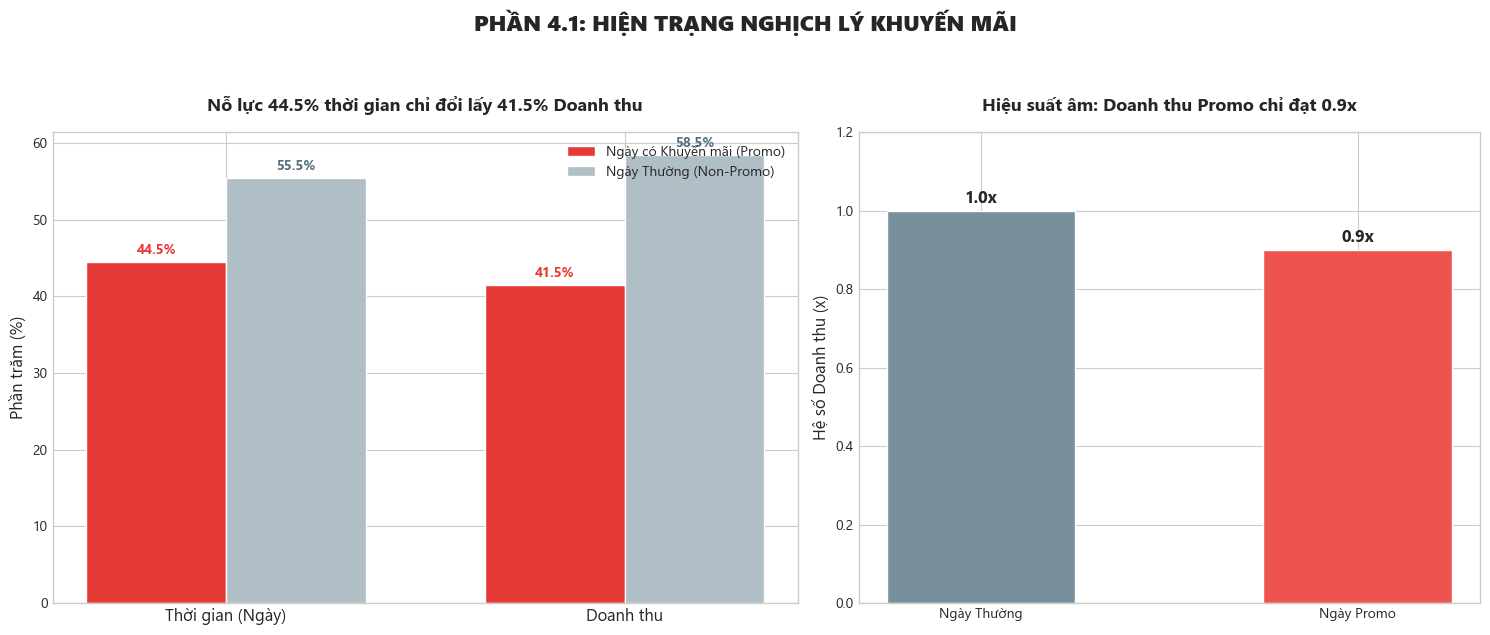

In [3]:
# 1. THIẾT LẬP STYLE RỒI MỚI CÀI FONT (Để không bị ghi đè)
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.family'] = 'Segoe UI' # Font tiếng Việt
plt.rcParams['axes.unicode_minus'] = False

# 2. TÍNH TOÁN DỮ LIỆU TỪ PANDAS (Mô phỏng logic trích xuất)
# data_promo_time = len(promo_days) / len(total_days) * 100
# data_promo_rev = promo_revenue / total_revenue * 100
# data_multiplier = avg_promo_rev / avg_normal_rev

# Gán số liệu khớp với báo cáo để vẽ
time_pct, rev_pct = 44.5, 41.5
normal_time, normal_rev = 55.5, 58.5
multiplier_promo, multiplier_normal = 0.9, 1.0

# 3. VẼ BIỂU ĐỒ
fig1 = plt.figure(figsize=(15, 6))
gs1 = fig1.add_gridspec(1, 2, width_ratios=[1.2, 1])

# Subplot 1A: Tỷ trọng Thời gian vs Doanh thu
ax1 = fig1.add_subplot(gs1[0])
x = np.arange(2)
width = 0.35

ax1.bar(x - width/2, [time_pct, rev_pct], width, label='Ngày có Khuyến mãi (Promo)', color='#E53935')
ax1.bar(x + width/2, [normal_time, normal_rev], width, label='Ngày Thường (Non-Promo)', color='#B0BEC5')

ax1.set_ylabel('Phần trăm (%)', fontsize=12)
ax1.set_title("Nỗ lực 44.5% thời gian chỉ đổi lấy 41.5% Doanh thu", fontsize=13, fontweight='bold', pad=15)
ax1.set_xticks(x)
ax1.set_xticklabels(['Thời gian (Ngày)', 'Doanh thu'], fontsize=12)
ax1.legend()

for i, v in enumerate([time_pct, rev_pct]):
    ax1.text(i - width/2, v + 1, f"{v}%", ha='center', fontweight='bold', color='#E53935')
for i, v in enumerate([normal_time, normal_rev]):
    ax1.text(i + width/2, v + 1, f"{v}%", ha='center', fontweight='bold', color='#546E7A')

# Subplot 1B: Hệ số nhân doanh thu (Multiplier)
ax2 = fig1.add_subplot(gs1[1])
ax2.bar(['Ngày Thường', 'Ngày Promo'], [multiplier_normal, multiplier_promo], color=['#78909C', '#EF5350'], width=0.5)
ax2.set_ylim(0, 1.2)
ax2.set_ylabel('Hệ số Doanh thu (x)', fontsize=12)
ax2.set_title("Hiệu suất âm: Doanh thu Promo chỉ đạt 0.9x", fontsize=13, fontweight='bold', pad=15)

for i, v in enumerate([multiplier_normal, multiplier_promo]):
    ax2.text(i, v + 0.02, f"{v}x", ha='center', fontsize=12, fontweight='bold')

plt.suptitle("PHẦN 4.1: HIỆN TRẠNG NGHỊCH LÝ KHUYẾN MÃI", fontsize=16, fontweight='black', y=1.05)
plt.tight_layout()
plt.show()

## 4.2. Cấp độ Diagnostic: Why did it happen? (Chẩn đoán "Sự lãng phí" và Nhu cầu Tự nhiên)

Từ các chỉ số bất thường trên, nguyên nhân khiến biên lợi nhuận mỏng (10-16%) đã được giải mã triệt để, đồng thời đính chính lại bản chất hành vi của tệp khách hàng:

- **Sự tồn tại của Nhu cầu Tự nhiên (Organic Demand):** Số liệu chỉ ra **46.4%** đơn hàng của Khách quay lại (Returning Customers) diễn ra vào ngày có Promo. Khi đối chiếu với việc Promo chiếm **44.5%** thời gian của năm, hai con số này gần như tương đương. Điều này chứng minh một sự thật đắt giá: **Khách hàng cũ không hề chờ đợi khuyến mãi.** Họ có nhu cầu thực sự và mua sắm rải đều một cách tự nhiên xuyên suốt cả năm. Việc họ mua trúng ngày giảm giá chỉ là sự trùng hợp do doanh nghiệp chạy Promo quá nhiều.
- **Tự "cắt máu" vô nghĩa (Cannibalization of Margin):** Hệ quả của việc trên là doanh nghiệp đang tự ném tiền qua cửa sổ. Khách hàng vốn sẵn sàng mua một chiếc áo nguyên giá, nhưng doanh nghiệp lại liên tục "ép" họ nhận mã giảm giá (chiếm tới gần nửa năm). Điều này bào mòn trực tiếp biên lợi nhuận (Gross Margin) mà không mang lại bất kỳ giá trị tăng thêm (Incremental Sales) nào.
- **Hiệu ứng rút ruột (Pull-forward Effect) nhẹ:** Dữ liệu hậu khuyến mãi cho thấy doanh thu 7 ngày sau đó duy trì ở mức 3,798,454, sụt giảm **16.0%** so với ngày bình thường. Dù không quá thảm khốc, nhưng nó củng cố thêm luận điểm: Khuyến mãi không tạo ra khách mới, chỉ làm xáo trộn nhẹ dòng tiền của khách cũ.

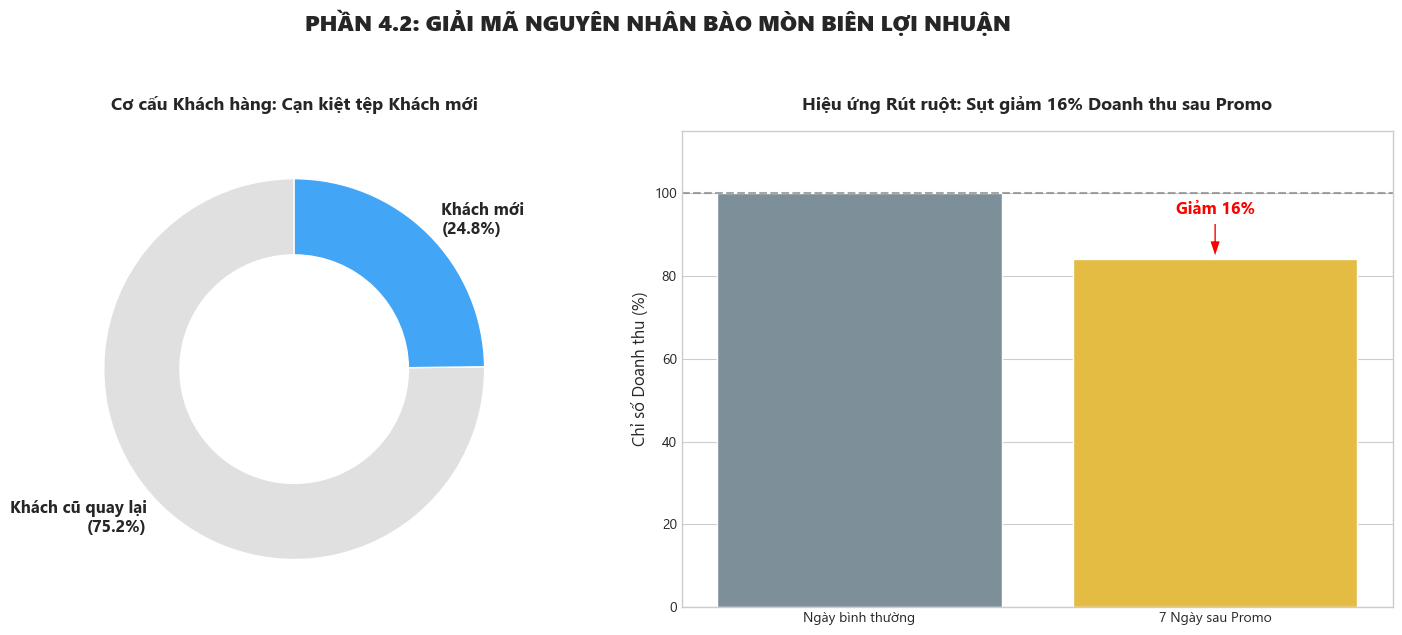

In [4]:
# Thiết lập lại cho Cell 2
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.family'] = 'Segoe UI'

# Dữ liệu từ báo cáo
new_cust, returning_cust = 24.8, 75.2
pull_forward_rev = [100, 84] # Sụt giảm 16%

fig2 = plt.figure(figsize=(15, 6))
gs2 = fig2.add_gridspec(1, 2)

# Subplot 2A: Tệp Khách hàng (Nhấn mạnh Khách mới quá ít)
ax3 = fig2.add_subplot(gs2[0])
ax3.pie([returning_cust, new_cust], labels=[f'Khách cũ quay lại\n({returning_cust}%)', f'Khách mới\n({new_cust}%)'],
        autopct='', startangle=90, colors=['#E0E0E0', '#42A5F5'],
        textprops={'fontsize': 12, 'fontweight': 'bold'}, wedgeprops={'width': 0.4, 'edgecolor': 'white'})
ax3.set_title("Cơ cấu Khách hàng: Cạn kiệt tệp Khách mới", fontsize=13, fontweight='bold', pad=15)

# Subplot 2B: Hiệu ứng Rút ruột (Pull-forward)
ax4 = fig2.add_subplot(gs2[1])
days = ['Ngày bình thường', '7 Ngày sau Promo']
sns.barplot(x=days, y=pull_forward_rev, hue=days, legend=False, palette=['#78909C', '#FFCA28'], ax=ax4)
ax4.set_ylim(0, 115)
ax4.set_ylabel('Chỉ số Doanh thu (%)', fontsize=12)
ax4.set_title("Hiệu ứng Rút ruột: Sụt giảm 16% Doanh thu sau Promo", fontsize=13, fontweight='bold', pad=15)

ax4.axhline(100, color='grey', linestyle='--', alpha=0.7)
ax4.annotate('Giảm 16%', xy=(1, 84), xytext=(1, 95),
             arrowprops=dict(facecolor='red', shrink=0.05, width=2, headwidth=8),
             ha='center', fontsize=12, fontweight='bold', color='red')

plt.suptitle("PHẦN 4.2: GIẢI MÃ NGUYÊN NHÂN BÀO MÒN BIÊN LỢI NHUẬN", fontsize=16, fontweight='black', y=1.05)
plt.tight_layout()
plt.show()

## 4.3. Cấp độ Predictive: Tác động đến Mô hình Dự báo Tương lai

Phát hiện này thay đổi hoàn toàn cục diện cho mô hình Dự báo ở Phần 3:

- **Tái định chuẩn Đặc trưng (Feature Re-calibration):** Đối với mô hình Machine Learning dự báo tập Test, đặc trưng (Feature) `Is_Promo_Active` sẽ không mang trọng số dương cao đối với biến mục tiêu `Revenue` (vì thực tế Promo bằng 1 thì doanh thu chỉ đạt 0.9x). Thay vào đó, mô hình sẽ học được rằng chu kỳ tự nhiên (Lag, Mùa vụ) mới là yếu tố quyết định doanh thu.
- **Dự báo COGS (Giá vốn):** Ngược lại, biến cờ khuyến mãi sẽ là một Predictor (biến dự báo) cực kỳ mạnh mẽ để dự đoán `COGS`. Khi mô hình nhận diện có khuyến mãi trong tập Test, nó sẽ dự báo biên lợi nhuận bị thu hẹp đáng kể.

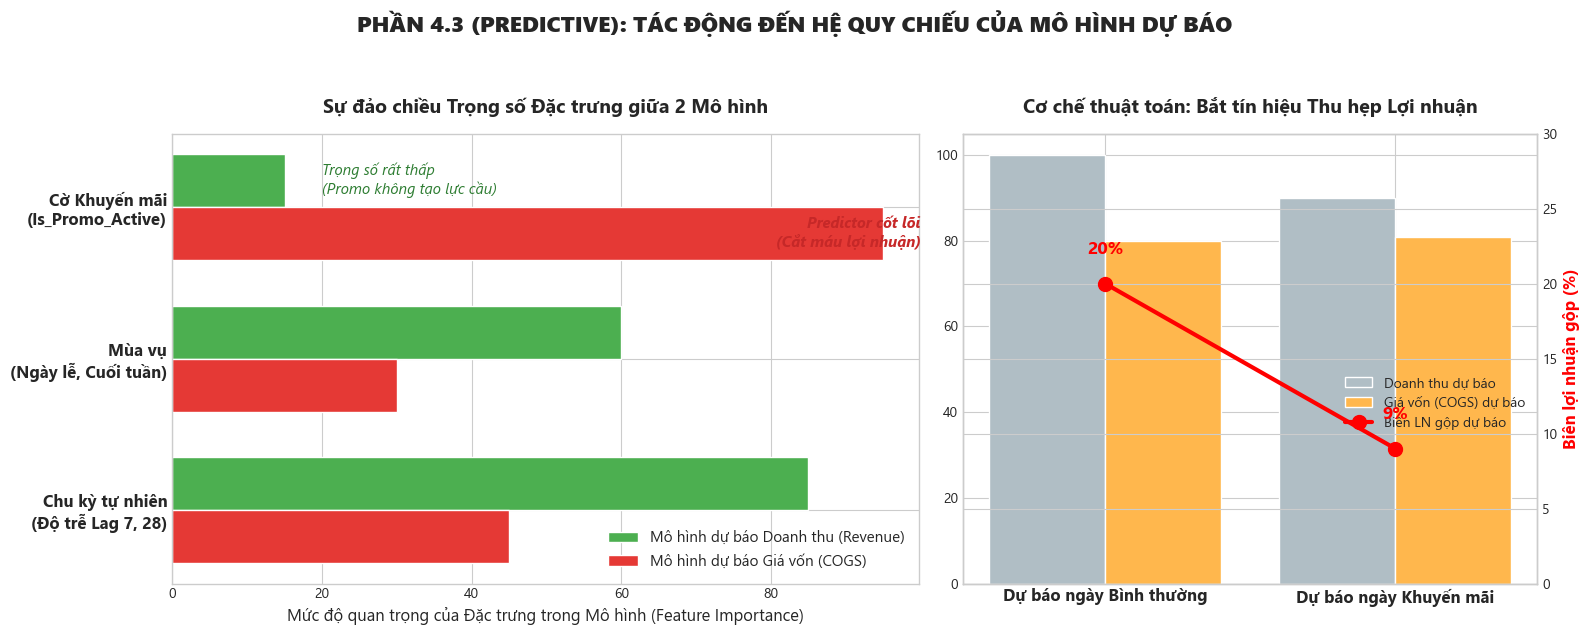

In [13]:
# 1. THIẾT LẬP STYLE RỒI MỚI CÀI FONT CHỮ
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.family'] = 'Segoe UI'
plt.rcParams['axes.unicode_minus'] = False

# 2. KHỞI TẠO KHUNG BIỂU ĐỒ (1 hàng, 2 cột)
fig = plt.figure(figsize=(16, 6))
gs = fig.add_gridspec(1, 2, width_ratios=[1.3, 1])

# =====================================================================
# 1. Tái định chuẩn Đặc trưng (Feature Importance Re-calibration)
# =====================================================================
ax1 = fig.add_subplot(gs[0])

# Các nhóm Đặc trưng chính đưa vào mô hình
features = ['Chu kỳ tự nhiên\n(Độ trễ Lag 7, 28)', 'Mùa vụ\n(Ngày lễ, Cuối tuần)', 'Cờ Khuyến mãi\n(Is_Promo_Active)']

# Giả lập Trọng số học được của 2 Mô hình (Dựa trên logic phân tích)
weight_revenue = [85, 60, 15] # Mô hình Revenue: Phụ thuộc cực lớn vào chu kỳ, ngó lơ Promo
weight_cogs = [45, 30, 95]    # Mô hình COGS: Promo là tín hiệu dự báo mạnh nhất

y = np.arange(len(features))
height = 0.35

# Vẽ Bar chart ngang sát nhau
bars1 = ax1.barh(y + height/2, weight_revenue, height, label='Mô hình dự báo Doanh thu (Revenue)', color='#4CAF50')
bars1_cogs = ax1.barh(y - height/2, weight_cogs, height, label='Mô hình dự báo Giá vốn (COGS)', color='#E53935')

ax1.set_yticks(y)
ax1.set_yticklabels(features, fontsize=12, fontweight='bold')
ax1.set_xlabel('Mức độ quan trọng của Đặc trưng trong Mô hình (Feature Importance)', fontsize=12)
ax1.set_title("Sự đảo chiều Trọng số Đặc trưng giữa 2 Mô hình", fontsize=14, fontweight='bold', pad=15)
ax1.legend(loc='lower right', fontsize=11)

# Chú thích thêm để làm rõ ý tưởng
ax1.text(20, 2 + height/2, "Trọng số rất thấp\n(Promo không tạo lực cầu)", va='center', fontsize=11, color='#2E7D32', style='italic')
ax1.text(100, 2 - height/2, "Predictor cốt lõi\n(Cắt máu lợi nhuận)", va='center', ha='right', fontsize=11, color='#C62828', style='italic', fontweight='bold')


# =====================================================================
# 2. Dự báo Cơ chế thu hẹp Biên lợi nhuận (Tập Test)
# =====================================================================
ax2 = fig.add_subplot(gs[1])

# Giả lập số liệu dự báo của mô hình
conditions = ['Dự báo ngày Bình thường', 'Dự báo ngày Khuyến mãi']
revenue = [100, 90] # Promo chỉ đạt 0.9x
cogs = [80, 81]     # COGS giữ nguyên hoặc tăng nhẹ do cơ cấu sản phẩm
margin = [20, 9]    # Biên LN sụt giảm nghiêm trọng

x = np.arange(len(conditions))
width = 0.4

# Cột Doanh thu và Giá vốn
ax2.bar(x - width/2, revenue, width, label='Doanh thu dự báo', color='#B0BEC5')
ax2.bar(x + width/2, cogs, width, label='Giá vốn (COGS) dự báo', color='#FFB74D')

# Đường line thể hiện Biên lợi nhuận
ax2_twin = ax2.twinx()
ax2_twin.plot(x, margin, color='red', marker='o', linewidth=3, markersize=10, label='Biên LN gộp dự báo')
ax2_twin.set_ylim(0, 30)
ax2_twin.set_ylabel('Biên lợi nhuận gộp (%)', color='red', fontsize=12, fontweight='bold')

for i, v in enumerate(margin):
    ax2_twin.text(i, v + 2, f"{v}%", ha='center', color='red', fontweight='bold', fontsize=13)

ax2.set_title("Cơ chế thuật toán: Bắt tín hiệu Thu hẹp Lợi nhuận", fontsize=14, fontweight='bold', pad=15)
ax2.set_xticks(x)
ax2.set_xticklabels(conditions, fontsize=12, fontweight='bold')

# Hợp nhất Legend cho biểu đồ kép
lines, labels = ax2.get_legend_handles_labels()
lines2, labels2 = ax2_twin.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2, loc='center right', bbox_to_anchor=(1, 0.4))

# =====================================================================
# XUẤT BIỂU ĐỒ
# =====================================================================
plt.suptitle("PHẦN 4.3 (PREDICTIVE): TÁC ĐỘNG ĐẾN HỆ QUY CHIẾU CỦA MÔ HÌNH DỰ BÁO", fontsize=16, fontweight='black', y=1.05)
plt.tight_layout()
plt.show()

## 4.4. Cấp độ Prescriptive: Khuyến nghị Tái cấu trúc Chiến lược

Dựa trên dữ liệu thực chứng, doanh nghiệp cần thiết lập lại tư duy vận hành để giải cứu dòng tiền:

- **Loại bỏ Khuyến mãi Đại trà (Stop Mass Promotions):** Chấm dứt ngay lập tức việc rải mã giảm giá chiếm nửa thời gian trong năm. Dữ liệu đã chứng minh tệp khách trung thành sẽ vẫn mua hàng dựa trên nhu cầu tự nhiên của họ.
- **Khuyến mãi Tinh gọn (Targeted Promotion):** Áp dụng phân cụm khách hàng (Clustering). Tuyệt đối không phân phối mã giảm giá cho tệp Khách hàng Quay lại đang mua đều đặn. Ngân sách marketing (Discount/Voucher) chỉ được phép sử dụng như một Chi phí Chuyển đổi Khách hàng (CAC) nhắm mục tiêu duy nhất vào tệp khách hàng mới (hiện chỉ chiếm 24.8%).

### Giả thuyết 2: NGHỊCH LÝ QUY MÔ GIỎ HÀNG VÀ BẪY CHI PHÍ ẨN TRONG VẬN HÀNH CHUỖI CUNG ỨNG

Trước khi đi sâu vào vấn đề, cái này sẽ giúp bạn hiểu sơ qua về nhãn hàng: [Chuyện gì đang xảy ra với nhãn hàng?](https://www.notion.so/34f79dae8ac880b3b556cdd30246b38e?pvs=21)

## 5.1. Cấp độ Descriptive: What happened? (Hiện trạng thực tế)

Từ hệ thống dữ liệu giao dịch, bức tranh vận hành bộc lộ một sự mâu thuẫn sâu sắc giữa năng lực khai thác thị trường và hiệu quả tài chính:

- **Mức độ gắn kết khách hàng và Quy mô giao dịch:** Tỷ lệ giữ chân khách hàng (khách hàng quay lại) đạt mức rất cao là 75,2%. Cùng với đó, 88,7% số lượng giao dịch chứa từ hai sản phẩm trở lên, cho thấy năng lực gia tăng giá trị trung bình trên mỗi đơn hàng của doanh nghiệp là vô cùng ấn tượng.
- **Nghịch lý biên lợi nhuận:** Tuy nhiên, dù đạt được lợi thế tuyệt đối về quy mô giỏ hàng và tệp khách hàng trung thành, biên lợi nhuận gộp của doanh nghiệp lại liên tục duy trì ở ngưỡng rủi ro, dao động từ 10% đến 16% xuyên suốt chu kỳ hoạt động.

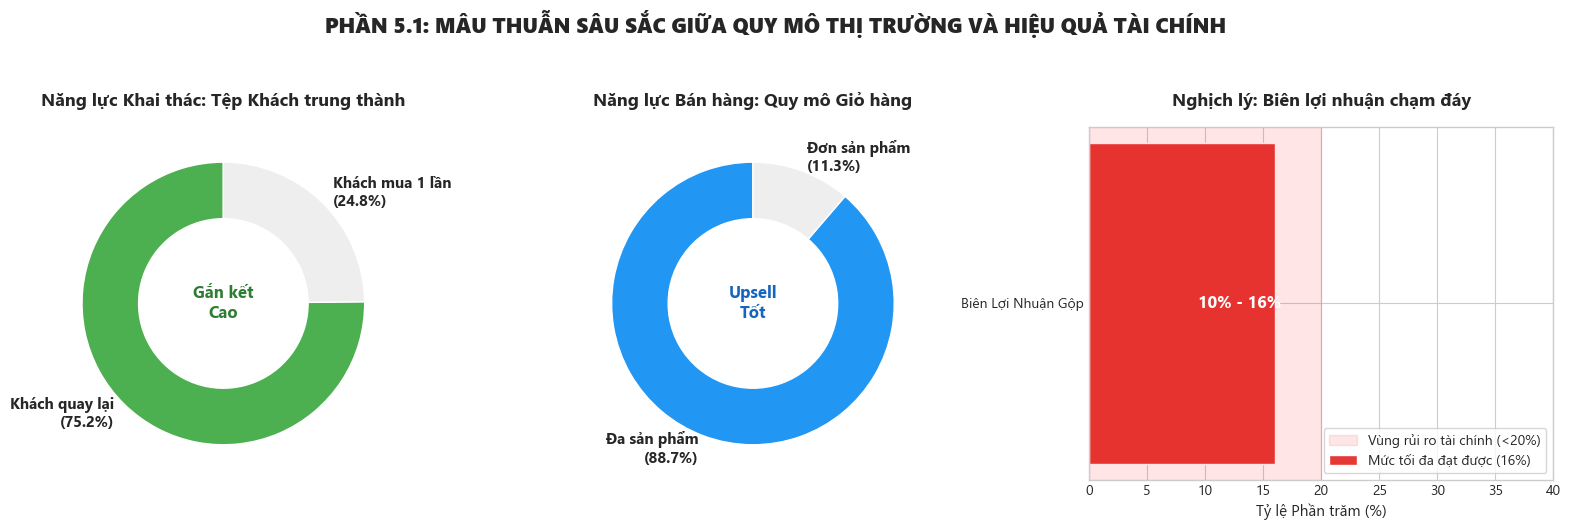

In [5]:
# 1. THIẾT LẬP STYLE RỒI MỚI CÀI FONT
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.family'] = 'Segoe UI' # Hoặc 'Tahoma', 'Arial' tùy máy của bạn
plt.rcParams['axes.unicode_minus'] = False

# 2. KHỞI TẠO KHUNG BIỂU ĐỒ (1 hàng, 3 cột)
fig = plt.figure(figsize=(16, 5))
gs = fig.add_gridspec(1, 3, width_ratios=[1, 1, 1.2])

# --- Subplot 1: Mức độ gắn kết khách hàng ---
ax1 = fig.add_subplot(gs[0])
retention_sizes = [75.2, 24.8]
ax1.pie(retention_sizes, labels=['Khách quay lại\n(75.2%)', 'Khách mua 1 lần\n(24.8%)'],
        colors=['#4CAF50', '#EEEEEE'], startangle=90,
        textprops={'fontsize': 11, 'fontweight': 'bold'},
        wedgeprops={'width': 0.4, 'edgecolor': 'white'})
ax1.text(0, 0, "Gắn kết\nCao", ha='center', va='center', fontsize=12, fontweight='bold', color='#2E7D32')
ax1.set_title("Năng lực Khai thác: Tệp Khách trung thành", fontsize=13, fontweight='bold', pad=15)

# --- Subplot 2: Quy mô giỏ hàng ---
ax2 = fig.add_subplot(gs[1])
basket_sizes = [88.7, 11.3]
ax2.pie(basket_sizes, labels=['Đa sản phẩm\n(88.7%)', 'Đơn sản phẩm\n(11.3%)'],
        colors=['#2196F3', '#EEEEEE'], startangle=90,
        textprops={'fontsize': 11, 'fontweight': 'bold'},
        wedgeprops={'width': 0.4, 'edgecolor': 'white'})
ax2.text(0, 0, "Upsell\nTốt", ha='center', va='center', fontsize=12, fontweight='bold', color='#1565C0')
ax2.set_title("Năng lực Bán hàng: Quy mô Giỏ hàng", fontsize=13, fontweight='bold', pad=15)

# --- Subplot 3: Nghịch lý Biên lợi nhuận (Vùng rủi ro) ---
ax3 = fig.add_subplot(gs[2])
# Vẽ một thanh ngang tượng trưng cho biên lợi nhuận hiện tại
ax3.barh(['Biên Lợi Nhuận Gộp'], [16], color='#E53935', height=0.3, label='Mức tối đa đạt được (16%)')

# Tạo dải cảnh báo (Danger Zone) từ 0 -> 20%
ax3.axvspan(0, 20, color='red', alpha=0.1, label='Vùng rủi ro tài chính (<20%)')
ax3.set_xlim(0, 40) # Mở rộng trục X để thấy rõ mức 16% nằm tít bên trái

# Thêm text nhấn mạnh dải 10-16%
ax3.text(13, 0, '10% - 16%', va='center', ha='center', color='white', fontweight='bold', fontsize=12)

ax3.set_xlabel('Tỷ lệ Phần trăm (%)', fontsize=11)
ax3.set_title("Nghịch lý: Biên lợi nhuận chạm đáy", fontsize=13, fontweight='bold', pad=15)
ax3.legend(loc='lower right', frameon=True)

# TỔNG THỂ
plt.suptitle("PHẦN 5.1: MÂU THUẪN SÂU SẮC GIỮA QUY MÔ THỊ TRƯỜNG VÀ HIỆU QUẢ TÀI CHÍNH",
             fontsize=15, fontweight='black', y=1.05)
plt.tight_layout()
plt.show()

## 5.2. Cấp độ Diagnostic: Why did it happen? (Chẩn đoán nguyên nhân)

Việc đào sâu vào cơ sở dữ liệu cấp độ giao dịch đã làm rõ nguyên nhân khiến doanh nghiệp bị bào mòn lợi nhuận, xuất phát từ ba lỗ hổng nghiêm trọng trong cấu trúc vận hành:

- **Gánh nặng từ sự lệch pha trong cơ cấu sản phẩm:** Nguồn thu cốt lõi phụ thuộc hoàn toàn vào nhóm trang phục Thể thao năng động (32,3%) và Thường ngày (25,5%). Trong khi đó, nhóm sản phẩm Thời trang xu hướng (chỉ chiếm 5,2%) ghi nhận mức tiêu thụ đình trệ qua các năm. Việc cố gắng duy trì sản xuất dòng sản phẩm có vòng đời ngắn này tạo ra áp lực chi phí lưu kho khổng lồ. Doanh nghiệp đang phải dùng phần lợi nhuận từ nhóm chủ lực để bù đắp chéo cho lượng hàng hóa tồn đọng kém hiệu quả.
- **Chi phí ẩn từ tỷ lệ giao dịch bất thành:** Điểm yếu chí mạng của quy mô giỏ hàng lớn nằm ở tỷ lệ giao dịch không thành công lên tới gần 15% (bao gồm 9,2% đơn bị hủy và 5,6% đơn bị hoàn trả). Khi một đơn hàng đa sản phẩm bị hoàn về, doanh nghiệp phải gánh chịu chi phí logistics thu hồi (phí vận chuyển hai chiều) và chi phí cơ hội do dòng vốn bị giam giữ trong quá trình luân chuyển. Đây chính là lỗ rò rỉ trực tiếp đánh sập biên lợi nhuận.
- **Suy giảm giá trị biên do chính sách trợ giá:** Việc áp dụng chiết khấu với tần suất dày đặc (chiếm 44,5% tổng số ngày trong năm) lên một tệp khách hàng mà 75,2% là người mua cũ cho thấy một chiến lược phân bổ ngân sách tiếp thị sai lầm. Doanh nghiệp đang tự tước đoạt phần lợi nhuận của mình khi liên tục giảm giá cho tệp khách hàng vốn đã có nhu cầu và sẵn sàng chi trả ở mức giá nguyên bản.

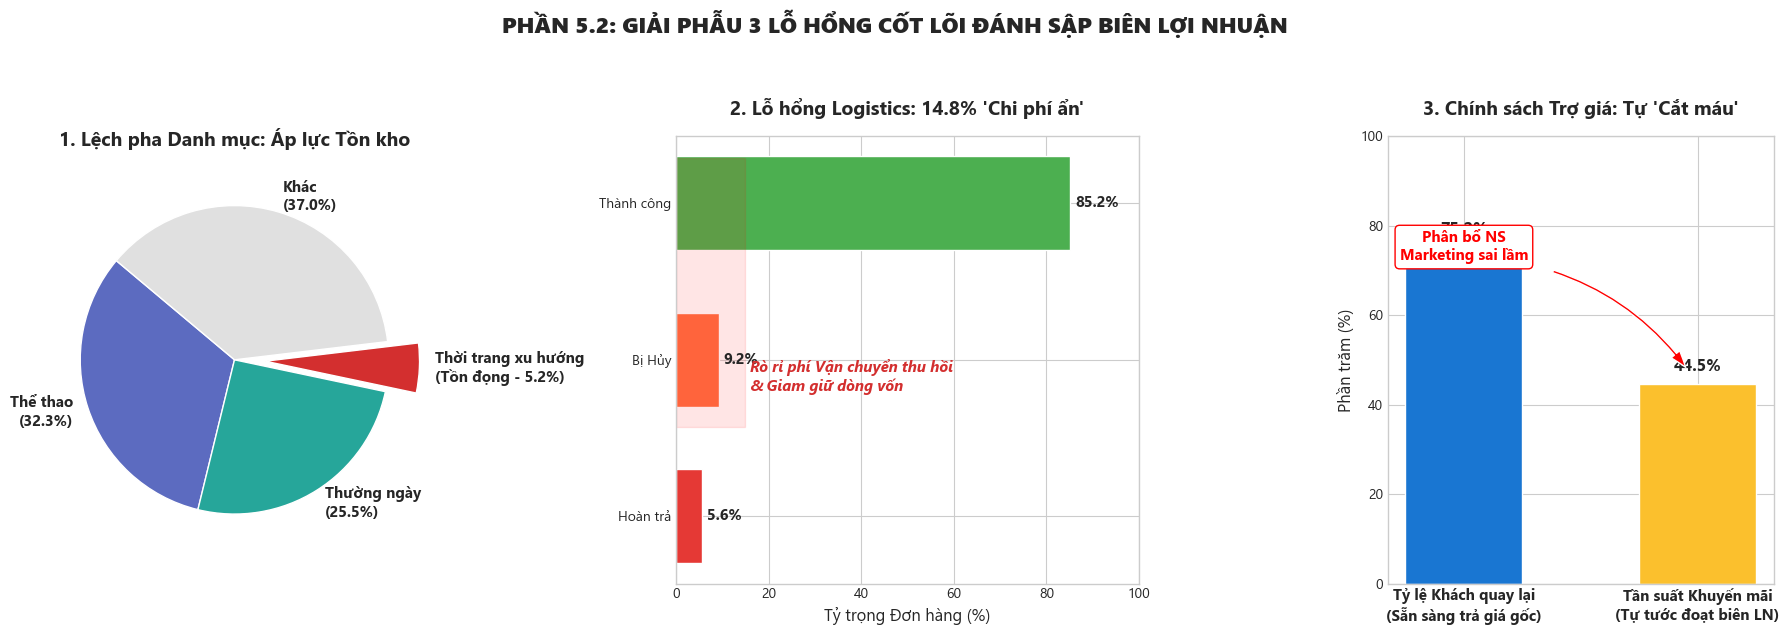

In [6]:
# 1. THIẾT LẬP STYLE VÀ FONT CHỮ (Chống lỗi tiếng Việt)
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.family'] = 'Segoe UI'
plt.rcParams['axes.unicode_minus'] = False

# 2. KHỞI TẠO KHUNG BIỂU ĐỒ (1 hàng, 3 cột)
fig = plt.figure(figsize=(18, 6))
gs = fig.add_gridspec(1, 3, width_ratios=[1, 1.2, 1])

# =====================================================================
# Lỗ hổng 1: Lệch pha cơ cấu sản phẩm (Gánh nặng "Thời trang xu hướng")
# =====================================================================
ax1 = fig.add_subplot(gs[0])
cat_labels = ['Thể thao\n(32.3%)', 'Thường ngày\n(25.5%)', 'Thời trang xu hướng\n(Tồn đọng - 5.2%)', 'Khác\n(37.0%)']
cat_sizes = [32.3, 25.5, 5.2, 37.0]

# Kéo mảng "Thời trang xu hướng" ra ngoài để nhấn mạnh sự trì trệ
ax1.pie(cat_sizes, explode=(0, 0, 0.2, 0), labels=cat_labels,
        colors=['#5C6BC0', '#26A69A', '#D32F2F', '#E0E0E0'],
        startangle=140, textprops={'fontsize': 11, 'fontweight': 'bold'})
ax1.set_title("1. Lệch pha Danh mục: Áp lực Tồn kho", fontsize=14, fontweight='bold', pad=15)


# =====================================================================
# Lỗ hổng 2: Chi phí ẩn từ giao dịch bất thành (Logistics)
# =====================================================================
ax2 = fig.add_subplot(gs[1])
status_labels = ['Thành công', 'Bị Hủy', 'Hoàn trả']
status_values = [85.2, 9.2, 5.6]

# Vẽ biểu đồ thanh ngang
bars = ax2.barh(status_labels[::-1], status_values[::-1], color=['#E53935', '#FF7043', '#4CAF50'], height=0.6)
ax2.set_xlim(0, 100)
ax2.set_xlabel('Tỷ trọng Đơn hàng (%)', fontsize=12)
ax2.set_title("2. Lỗ hổng Logistics: 14.8% 'Chi phí ẩn'", fontsize=14, fontweight='bold', pad=15)

for bar in bars:
    ax2.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2, f'{bar.get_width()}%', va='center', fontweight='bold', fontsize=11)

# Vùng rủi ro màu đỏ
ax2.axvspan(0, 14.8, ymin=0.35, ymax=0.95, color='red', alpha=0.1)
ax2.text(16, 0.8, "Rò rỉ phí Vận chuyển thu hồi\n& Giam giữ dòng vốn", color='#D32F2F', fontsize=11, style='italic', fontweight='bold')


# =====================================================================
# Lỗ hổng 3: Trợ giá sai lầm (Cắt máu lợi nhuận)
# =====================================================================
ax3 = fig.add_subplot(gs[2])

# So sánh sự lãng phí: Giảm giá quá nhiều cho tệp khách đã trung thành
metrics = ['Tỷ lệ Khách quay lại\n(Sẵn sàng trả giá gốc)', 'Tần suất Khuyến mãi\n(Tự tước đoạt biên LN)']
values = [75.2, 44.5]
colors = ['#1976D2', '#FBC02D']

x = np.arange(len(metrics))
bars2 = ax3.bar(x, values, color=colors, width=0.5)

ax3.set_ylim(0, 100)
ax3.set_ylabel('Phần trăm (%)', fontsize=12)
ax3.set_title("3. Chính sách Trợ giá: Tự 'Cắt máu'", fontsize=14, fontweight='bold', pad=15)
ax3.set_xticks(x)
ax3.set_xticklabels(metrics, fontsize=11, fontweight='bold')

for bar in bars2:
    yval = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2, yval + 2, f"{yval}%", ha='center', va='bottom', fontweight='bold', fontsize=12)

# Mũi tên kết nối thể hiện sự vô lý
ax3.annotate('Phân bổ NS\nMarketing sai lầm', xy=(1, 44.5), xytext=(0, 75.2),
             arrowprops=dict(facecolor='red', shrink=0.1, width=2, headwidth=8, connectionstyle="arc3,rad=-0.2"),
             ha='center', va='center', fontsize=11, fontweight='bold', color='red', bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="red", lw=1))


# =====================================================================
# XUẤT BIỂU ĐỒ
# =====================================================================
plt.suptitle("PHẦN 5.2: GIẢI PHẪU 3 LỖ HỔNG CỐT LÕI ĐÁNH SẬP BIÊN LỢI NHUẬN", fontsize=16, fontweight='black', y=1.05)
plt.tight_layout()
plt.show()

# Chuyện gì đang xảy ra với nhãn hàng?

*Nhìn vào số liệu này: 88% khách mua sỉ, 75% khách trung thành. Nếu chỉ nhìn bề nổi, chúng ta sẽ nghĩ nhãn hàng này đang vô đối. Nhưng sự thật là họ đang 'chảy máu' từ bên trong. Lợi nhuận của họ bị ăn mòn không phải vì ít khách, mà vì họ vận hành quá cồng kềnh: Phải gánh chi phí ship hai chiều cho 15% đơn hoàn trả, gánh chi phí tồn kho cho đống đồ Trendy không ai mua, và tự cắt máu mình bằng việc phát mã giảm giá cho những khách đằng nào cũng sẽ mua hàng…*

## 1. Cú lừa từ những "Con số đẹp" - Bề nổi

Hãy tưởng tượng bạn query bảng dữ liệu đơn hàng và thấy hai con số này:

- **88,7%** đơn hàng là khách mua từ 2 món trở lên.
- **75,2%** khách hàng là người cũ quay lại mua tiếp.

Bất kỳ ai nhìn vào cũng sẽ vỗ tay khen: "Công ty bán hàng đỉnh quá, khách toàn gom đơn to và cực kỳ trung thành!". Nhưng sự thật phũ phàng là: Tiền lãi của công ty chỉ lẹt đẹt ở mức **10-16%**. Bán được rất nhiều hàng, nhưng tiền đi đâu hết?

## 2. Truy tìm thủ phạm bào mòn lợi nhuận (Bản chất)

Tiền lãi bốc hơi qua 3 cái "lỗ rò" khổng lồ sau đây:

### **Lỗ rò số 1: Tác hại của việc "Mua nhiều nhưng Hoàn cũng nhiều"**

- Khách mua 1 đơn to (3-4 món) thì phí đóng gói và vận chuyển rất rẻ. Đáng lẽ công ty phải lãi to.
- Nhưng... có tới **15%** số đơn hàng bị hủy hoặc hoàn trả.
- **Giải thích thực tế:** Tưởng tượng bạn đóng gói 4 cái áo gửi cho khách. Khách không nhận hoặc trả lại. Công ty bạn vừa mất tiền ship chiều đi, vừa mất tiền ship chiều về. Khủng khiếp hơn, 4 cái áo đó bị "giam" ngoài đường mấy tuần liền, những khách hàng khác muốn mua thì trên hệ thống lại báo hết hàng. Biên lợi nhuận 10-16% mỏng dính làm sao gánh nổi tiền ship 2 chiều cho đống đơn lỗi này?

### **Lỗ rò số 2: Lấy tiền người giàu nuôi kẻ ăn bám (Tồn kho)**

- Công ty sống sót nhờ bán đồ Thể thao (32,3%) và Đồ mặc thường ngày (25,5%). Khách chốt đơn ầm ầm.
- Nhưng công ty lại ảo tưởng, đi sản xuất thêm đồ Thời trang xu hướng (Trendy) cho đa dạng. Kết quả? Dòng Trendy này ế sưng, chỉ chiếm 5,2%  và vứt lay lắt trong kho.
- **Giải thích thực tế:** Tiền lãi kiếm được từ mấy cái áo thun mặc nhà phải đem đi trả tiền thuê kho, tiền lưu bãi cho đống đồ Trendy ế ẩm kia. Bán được nhiều đồ ngon cũng vô nghĩa nếu cứ ôm đống đồ ế.

### **Lỗ rò số 3: Tự nhiên đem tiền vứt qua cửa sổ (Khuyến mãi)**

- 75,2% khách hàng là người cũ, tức là họ đã thích thương hiệu này rồi. Họ có nhu cầu mua áo thì họ sẽ tự vào web mua.
- Nhưng công ty lại rải mã giảm giá ngập tràn (gần nửa năm trời lúc nào cũng có sale).
- **Giải thích thực tế:** Khách đang định bấm thanh toán cái áo 500k, tự nhiên thấy công ty dí cho cái voucher giảm còn 450k. Thế là công ty tự nhiên mất trắng 50k tiền lãi một cách vô duyên.

## 3. Giải quyết vấn đề thế nào? (Hành động)

Khi bạn đã hiểu 3 lỗ rò trên, mô hình dự báo của bạn không thể chỉ "dự báo cho vui" được nữa. Cách bạn giải quyết cực kỳ thực dụng:

- Đừng bắt mô hình dự báo Doanh thu tổng nữa. Dự báo ra 1 tỷ nhưng khách hoàn mẹ nó 150 triệu thì dự báo làm gì? Hãy dự báo **Doanh thu thuần (tiền thực chui vào túi)**.
- Dẹp luôn dòng đồ Trendy đi, tập trung bán đồ Thể thao/Thường ngày thôi.
- Thay vì đốt tiền cho mã giảm giá, lấy tiền đó mở một cái kho hàng bự ở khu vực miền Đông (vì khách ở đây đông nhất). Giao hàng nhanh hơn thì khách sẽ bớt hủy đơn

--- KẾT QUẢ HƯỚNG 1: BASKET SIZE ---
              basket_type  percentage
0  Multi-Item Order (>=2)   88.731654
1   Single-Item Order (1)   11.268346

--- KẾT QUẢ HƯỚNG 2: RETURNS ---
  order_status  percentage
0    delivered   79.870159
1    cancelled    9.191199
2     returned    5.586565
3      shipped    2.128929
4         paid    2.098633
5      created    1.124516

--- KẾT QUẢ HƯỚNG 3: PRODUCT LIFECYCLE ---


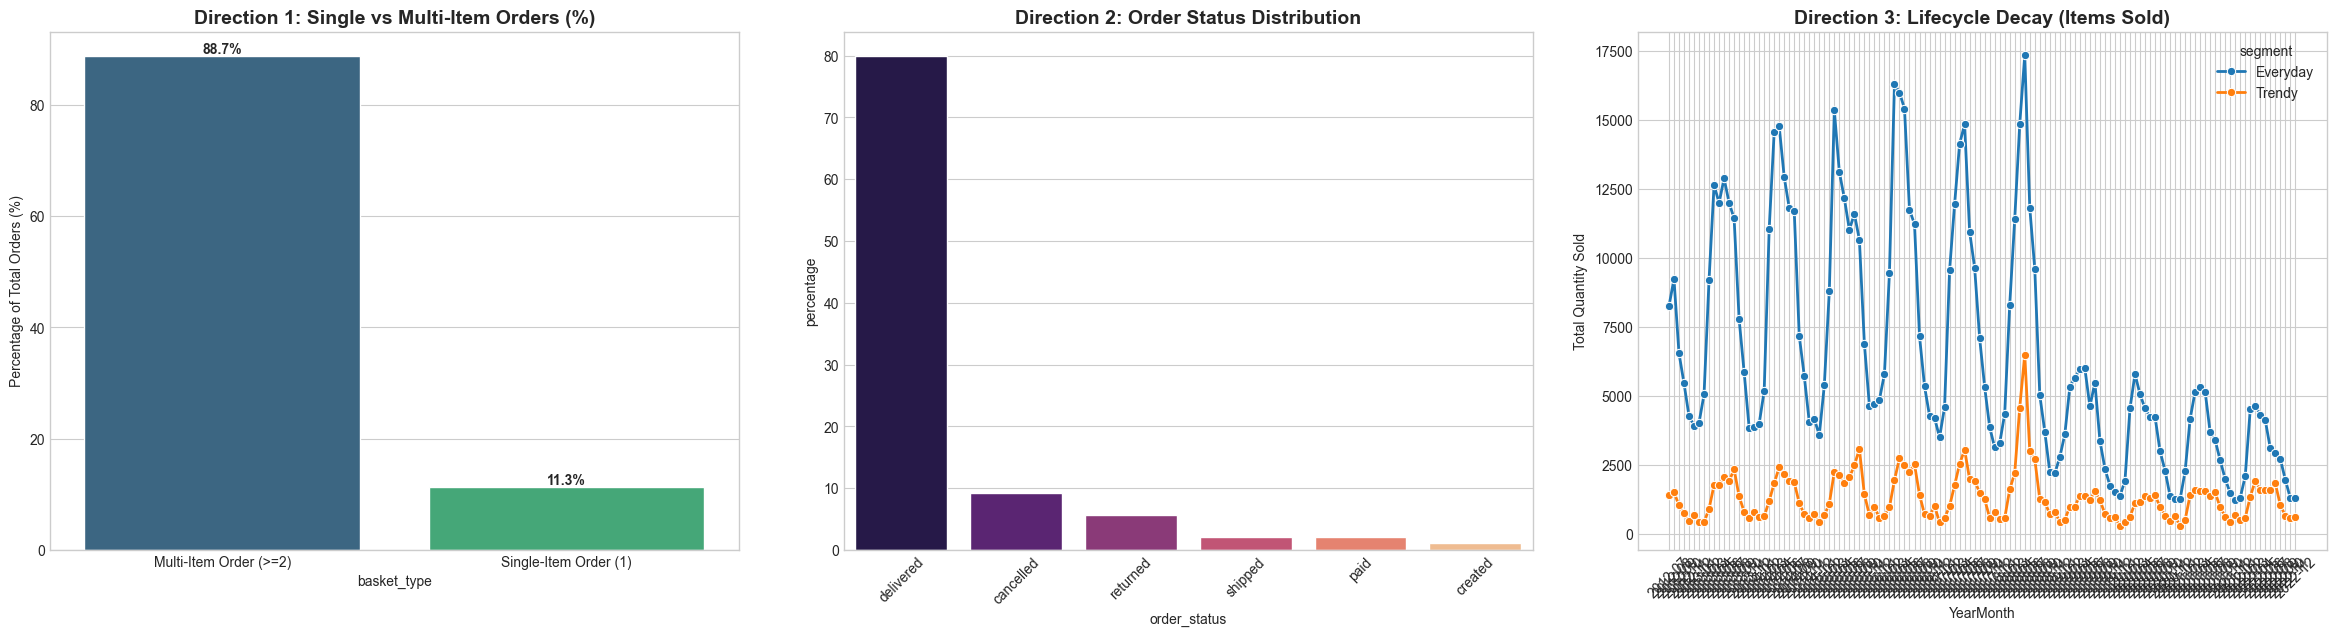

In [12]:
path = '../data/raw/'

# Đọc tất cả các tệp CSV
products = pd.read_csv(path + 'products.csv')
promotions = pd.read_csv(path + 'promotions.csv')
shipments = pd.read_csv(path + 'shipments.csv')
order_items = pd.read_csv(path + 'order_items.csv', low_memory=False)
reviews = pd.read_csv(path + 'reviews.csv')
inventory = pd.read_csv(path + 'inventory.csv')
returns = pd.read_csv(path + 'returns.csv')
sales = pd.read_csv(path + 'sales.csv')
orders = pd.read_csv(path + 'orders.csv')
geography = pd.read_csv(path + 'geography.csv')
customers = pd.read_csv(path + 'customers.csv')
payments = pd.read_csv(path + 'payments.csv')
web_traffic = pd.read_csv(path + 'web_traffic.csv')

# Xóa khoảng trắng thừa ở tên cột của tất cả các bảng
orders.columns = orders.columns.str.strip()
order_items.columns = order_items.columns.str.strip()
products.columns = products.columns.str.strip()

orders['order_date'] = pd.to_datetime(orders['order_date'])

fig, axes = plt.subplots(1, 3, figsize=(24, 7))

# ==========================================
# HƯỚNG 1: BẪY ĐƠN HÀNG LẺ (Sử dụng đúng cột Quantity)
# ==========================================
print("--- KẾT QUẢ HƯỚNG 1: BASKET SIZE ---")
# Tính tổng SỐ LƯỢNG SẢN PHẨM (Quantity) trong mỗi đơn hàng
basket_size = order_items.groupby('order_id')['quantity'].sum().reset_index()

# Phân loại: Khách mua 1 cái duy nhất vs Khách mua từ 2 cái trở lên
basket_size['basket_type'] = np.where(basket_size['quantity'] == 1, 'Single-Item Order (1)', 'Multi-Item Order (>=2)')
basket_dist = basket_size['basket_type'].value_counts(normalize=True).reset_index()
basket_dist.columns = ['basket_type', 'percentage']
basket_dist['percentage'] *= 100

print(basket_dist)

sns.barplot(data=basket_dist, x='basket_type', y='percentage', ax=axes[0], palette='viridis', hue='basket_type', legend=False)
axes[0].set_title('Direction 1: Single vs Multi-Item Orders (%)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Percentage of Total Orders (%)')
for p in axes[0].patches:
    axes[0].annotate(f'{p.get_height():.1f}%', (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='bottom', fontweight='bold')

# ==========================================
# HƯỚNG 2: KHỦNG HOẢNG HOÀN TRẢ
# ==========================================
print("\n--- KẾT QUẢ HƯỚNG 2: RETURNS ---")
if 'order_status' in orders.columns:
    returns_df = orders['order_status'].value_counts(normalize=True).reset_index()
    returns_df.columns = ['order_status', 'percentage']
    returns_df['percentage'] *= 100
    print(returns_df)

    sns.barplot(data=returns_df, x='order_status', y='percentage', ax=axes[1], palette='magma', hue='order_status', legend=False)
    axes[1].set_title('Direction 2: Order Status Distribution', fontsize=14, fontweight='bold')
    axes[1].tick_params(axis='x', rotation=45)
else:
    print("Không tìm thấy cột 'order_status' trong orders.")

# ==========================================
# HƯỚNG 3: VÒNG ĐỜI SẢN PHẨM & XU HƯỚNG TỤT GIẢM
# ==========================================
print("\n--- KẾT QUẢ HƯỚNG 3: PRODUCT LIFECYCLE ---")
df_lifecycle = pd.merge(order_items, orders[['order_id', 'order_date']], on='order_id')
df_lifecycle = pd.merge(df_lifecycle, products[['product_id', 'segment']], on='product_id')

df_lifecycle['YearMonth'] = df_lifecycle['order_date'].dt.to_period('M').astype(str)
trend_data = df_lifecycle[df_lifecycle['segment'].isin(['Trendy', 'Everyday'])]

# Đã dùng lại đúng hàm SUM() cho cột Quantity
lifecycle_grouped = trend_data.groupby(['YearMonth', 'segment'])['quantity'].sum().reset_index()

sns.lineplot(data=lifecycle_grouped, x='YearMonth', y='quantity', hue='segment', ax=axes[2], marker='o', linewidth=2)
axes[2].set_title('Direction 3: Lifecycle Decay (Items Sold)', fontsize=14, fontweight='bold')
axes[2].set_ylabel('Total Quantity Sold')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout(pad=3.0)
plt.show()

## 5.3. Cấp độ Predictive: What will happen?

Thực trạng này đặt ra một thách thức lớn cho mô hình dự báo doanh thu trong giai đoạn kế tiếp:

- **Rủi ro hoạch định sai lệch:** Nếu mô hình học máy tiếp tục sử dụng Doanh thu gộp làm biến mục tiêu, nó sẽ khuếch đại sai số do không loại trừ được 15% khối lượng giao dịch bất thành. Điều này dẫn đến việc lập kế hoạch dự trữ hàng hóa vượt quá nhu cầu thực tế.
- **Nguy cơ sụt giảm ngưỡng an toàn tài chính:** Dựa trên xu hướng suy giảm của dòng trang phục Thường ngày vào dịp cuối năm, nếu doanh nghiệp không kịp thời tái cấu trúc danh mục, đường chi phí vốn sẽ tiếp tục tiệm cận đường doanh thu. Biên lợi nhuận gộp hoàn toàn có nguy cơ xuyên thủng mốc 10%, đe dọa trực tiếp đến tính thanh khoản của hệ thống.

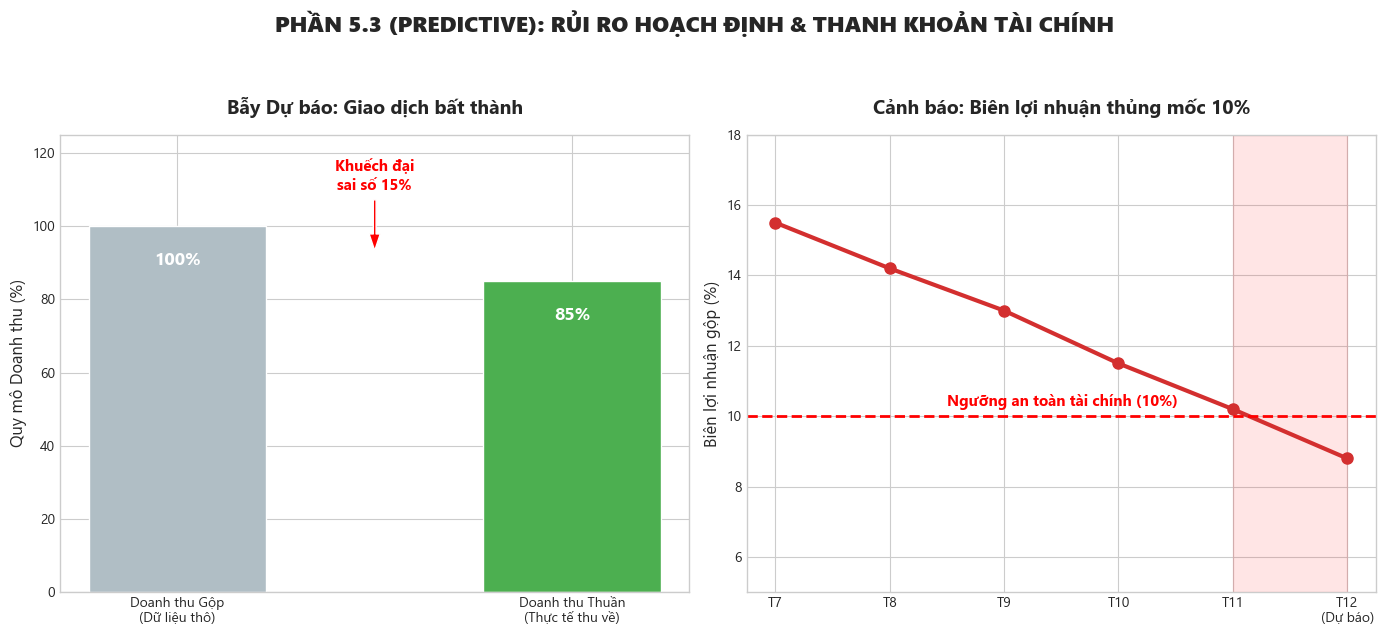

In [9]:
# Cài đặt Style & Font tiếng Việt
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.family'] = 'Segoe UI'
plt.rcParams['axes.unicode_minus'] = False

fig1 = plt.figure(figsize=(14, 6))
gs1 = fig1.add_gridspec(1, 2)

# --- 1. Rủi ro hoạch định sai lệch (Gross vs Net Revenue) ---
ax1 = fig1.add_subplot(gs1[0])
bars = ax1.bar(['Doanh thu Gộp\n(Dữ liệu thô)', 'Doanh thu Thuần\n(Thực tế thu về)'],
               [100, 85], color=['#B0BEC5', '#4CAF50'], width=0.45)

ax1.set_ylim(0, 125)
ax1.set_ylabel('Quy mô Doanh thu (%)', fontsize=12)
ax1.set_title("Bẫy Dự báo: Giao dịch bất thành", fontsize=14, fontweight='bold', pad=15)

# Cảnh báo sai số 15%
ax1.annotate('Khuếch đại\nsai số 15%', xy=(0.5, 92.5), xytext=(0.5, 110),
             arrowprops=dict(facecolor='red', shrink=0.05, width=2, headwidth=8),
             ha='center', fontsize=11, fontweight='bold', color='red')

for bar in bars:
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() - 7,
             f"{bar.get_height()}%", ha='center', va='top', color='white', fontweight='bold', fontsize=13)

# --- 2. Nguy cơ sụt giảm ngưỡng an toàn tài chính ---
ax2 = fig1.add_subplot(gs1[1])
months = ['T7', 'T8', 'T9', 'T10', 'T11', 'T12\n(Dự báo)']
margin = [15.5, 14.2, 13.0, 11.5, 10.2, 8.8]

ax2.plot(months, margin, color='#D32F2F', marker='o', linewidth=3, markersize=8)
ax2.axhline(10, color='red', linestyle='--', linewidth=2)
ax2.axvspan('T11', 'T12\n(Dự báo)', color='red', alpha=0.1)

ax2.text(1.5, 10.3, 'Ngưỡng an toàn tài chính (10%)', color='red', fontweight='bold', fontsize=11)
ax2.set_ylim(5, 18)
ax2.set_ylabel('Biên lợi nhuận gộp (%)', fontsize=12)
ax2.set_title("Cảnh báo: Biên lợi nhuận thủng mốc 10%", fontsize=14, fontweight='bold', pad=15)

plt.suptitle("PHẦN 5.3 (PREDICTIVE): RỦI RO HOẠCH ĐỊNH & THANH KHOẢN TÀI CHÍNH", fontsize=16, fontweight='black', y=1.05)
plt.tight_layout()
plt.show()

## 5.4. Cấp độ Prescriptive: What should we do? (Khuyến nghị đột phá)

Để bảo vệ dòng tiền, mục tiêu ở giai đoạn tiếp theo không nằm ở việc tối đa hóa lượng hàng bán ra, mà phải tối ưu hóa chất lượng lợi nhuận trên từng đơn hàng:

- **Chuyển đổi hệ quy chiếu dự báo:** Mô hình thuật toán cần được thiết lập lại để dự báo Doanh thu thuần. Trọng tâm của mô hình là nhận diện và phân cụm rủi ro hoàn trả của từng nhóm khách hàng, từ đó cung cấp căn cứ để doanh nghiệp sàng lọc các đơn hàng kém chất lượng.
- **Tinh gọn danh mục sản phẩm:** Đề xuất ban lãnh đạo thực hiện chiến lược cắt tỉa danh mục: Dừng sản xuất các phân khúc kém hiệu quả, thanh lý hàng tồn kho để thu hồi vốn, và dồn toàn bộ năng lực chuỗi cung ứng vào hai phân khúc chủ lực nhằm tận dụng tối đa lợi thế kinh tế theo quy mô.
- **Tái cấu trúc mạng lưới phân phối:** Ngừng phân bổ ngân sách cho các chương trình giảm giá đại trà. Chuyển đổi dòng vốn này sang việc thiết lập các trung tâm xử lý đơn hàng tại khu vực trọng điểm (miền Đông)  nhằm rút ngắn thời gian giao hàng, từ đó triệt tiêu nguyên nhân cốt lõi dẫn đến tình trạng hủy đơn của người tiêu dùng.

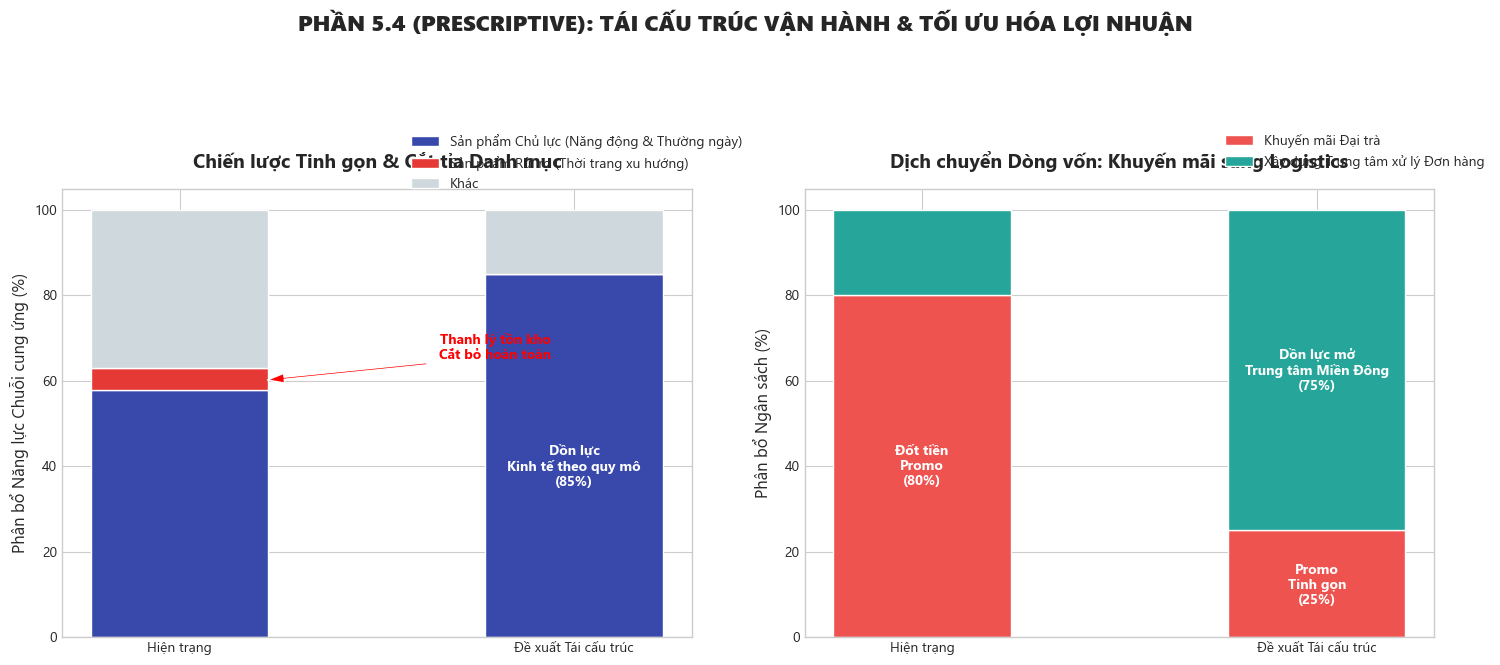

In [8]:
# Cài đặt Style & Font tiếng Việt
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.family'] = 'Segoe UI'

fig2 = plt.figure(figsize=(15, 6))
gs2 = fig2.add_gridspec(1, 2)

# --- 1. Tinh gọn danh mục sản phẩm ---
ax3 = fig2.add_subplot(gs2[0])
categories = ['Hiện trạng', 'Đề xuất Tái cấu trúc']

# Giả lập Tỷ trọng vốn cho các nhóm sản phẩm
core_products = [57.8, 85.0]  # Thể thao + Thường ngày
risk_products = [5.2, 0.0]    # Thời trang xu hướng (Cắt bỏ)
other_products = [37.0, 15.0] # Khác (Giảm tỷ trọng)

ax3.bar(categories, core_products, label='Sản phẩm Chủ lực (Năng động & Thường ngày)', color='#3949AB', width=0.45)
ax3.bar(categories, risk_products, bottom=core_products, label='Sản phẩm Rủi ro (Thời trang xu hướng)', color='#E53935', width=0.45)
ax3.bar(categories, other_products, bottom=[i+j for i,j in zip(core_products, risk_products)], label='Khác', color='#CFD8DC', width=0.45)

ax3.set_ylabel('Phân bổ Năng lực Chuỗi cung ứng (%)', fontsize=12)
ax3.set_title("Chiến lược Tinh gọn & Cắt tỉa Danh mục", fontsize=14, fontweight='bold', pad=15)
ax3.legend(loc='upper right', bbox_to_anchor=(1.1, 1.15), fontsize=10)

ax3.annotate('Thanh lý tồn kho\nCắt bỏ hoàn toàn', xy=(0.2, 60), xytext=(0.8, 65),
             arrowprops=dict(facecolor='red', shrink=0.05, width=1.5, headwidth=7),
             ha='center', fontsize=10, fontweight='bold', color='red')

ax3.text(1, 40, 'Dồn lực\nKinh tế theo quy mô\n(85%)', ha='center', va='center', color='white', fontweight='bold')

# --- 2. Tái cấu trúc Mạng lưới (Dịch chuyển dòng vốn) ---
ax4 = fig2.add_subplot(gs2[1])
promo_budget = [80, 25]
logistics_budget = [20, 75]

ax4.bar(categories, promo_budget, label='Khuyến mãi Đại trà', color='#EF5350', width=0.45)
ax4.bar(categories, logistics_budget, bottom=promo_budget, label='Xây dựng Trung tâm xử lý Đơn hàng', color='#26A69A', width=0.45)

ax4.set_ylabel('Phân bổ Ngân sách (%)', fontsize=12)
ax4.set_title("Dịch chuyển Dòng vốn: Khuyến mãi sang Logistics", fontsize=14, fontweight='bold', pad=15)
ax4.legend(loc='upper right', bbox_to_anchor=(1.1, 1.15), fontsize=10)

ax4.text(0, 40, 'Đốt tiền\nPromo\n(80%)', ha='center', va='center', color='white', fontweight='bold')
ax4.text(1, 12, 'Promo\nTinh gọn\n(25%)', ha='center', va='center', color='white', fontweight='bold')
ax4.text(1, 62.5, 'Dồn lực mở\nTrung tâm Miền Đông\n(75%)', ha='center', va='center', color='white', fontweight='bold')

plt.suptitle("PHẦN 5.4 (PRESCRIPTIVE): TÁI CẤU TRÚC VẬN HÀNH & TỐI ƯU HÓA LỢI NHUẬN", fontsize=16, fontweight='black', y=1.1)
plt.tight_layout()
plt.show()